# 03 — Correlation and cross-correlation

**Dataset:** `aim_2023`

**Question:** Which channels show consistent recurrence periods and sensor lags?

## Method

Compute overlap-normalized channel autocorrelation and pairwise cross-correlation within bounded lag ranges.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_classical import render_correlation_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,channel_lag_consensus,train,mean_lag_mad_s,2.371429,7,none
1,channel_lag_consensus,validation,mean_lag_mad_s,0.250000,1,none
2,channel_lag_consensus,test,mean_lag_mad_s,5.000000,2,none
3,channel_lag_consensus,all,mean_lag_mad_s,2.685000,10,none
4,sensor_cross_correlation,train,median_absolute_peak_correlation,0.655753,110,none
5,sensor_cross_correlation,validation,median_absolute_peak_correlation,0.741878,30,none
6,sensor_cross_correlation,test,median_absolute_peak_correlation,0.442053,40,none
7,sensor_cross_correlation,all,median_absolute_peak_correlation,0.655753,180,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,50,10,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,50,5,InlineAcc,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lag_s,50.0,NaN,NaN,NaN,33.108,14.309827,15.05,20.425,30.475,45.9,59.25
correlation,50.0,NaN,NaN,NaN,0.160608,0.062684,0.038694,0.115911,0.167001,0.198574,0.340034
segment_id,50,5,channel_0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,50.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
end_s,50.0,NaN,NaN,NaN,188.85,111.729858,33.95,107.95,193.45,228.95,456.95
prediction_kind,50,1,channel_recurrence_period,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,50.0,NaN,NaN,NaN,0.160608,0.062684,0.038694,0.115911,0.167001,0.198574,0.340034
label_status,50,1,provisional_unverified,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,median,std,min,max
recording_id,,,,,,
8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe31b6db9ad4f9510f8c5,5,0.253193,0.247420,0.057667,0.178648,0.340034
18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b55502d04ff71359269,5,0.198801,0.203607,0.030690,0.160628,0.237398
27937681c8199780c6cbce603f217d5a4457c351e84fa3cd7cfc62bfd270c550,5,0.190762,0.184174,0.034694,0.151900,0.246157
bace0e92b25324e8afbd0e5f6698b01a921780a2385e02419965fa97e3e796c4,5,0.176730,0.176242,0.035244,0.123644,0.221776
b185f43818b8ff3aba325752922bbbf37fd094f1e282887487651e0a5c8f6c7a,5,0.177161,0.174326,0.040954,0.132102,0.240730
4975a35d789765b9299480af66d6a5af5166fef074cef80facbac97409b84d07,5,0.180709,0.173374,0.038160,0.144259,0.236365
5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba70d3674bafd4f16fc15,5,0.140687,0.123656,0.048486,0.109606,0.225389
dc8bf44eb4cc0becf1c5ebe252a515c98193744c2031498501de80e036899758,5,0.130805,0.122361,0.027705,0.104482,0.176058
9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e7211426769a6b2ce6f86,5,0.095738,0.094582,0.008237,0.088698,0.109353


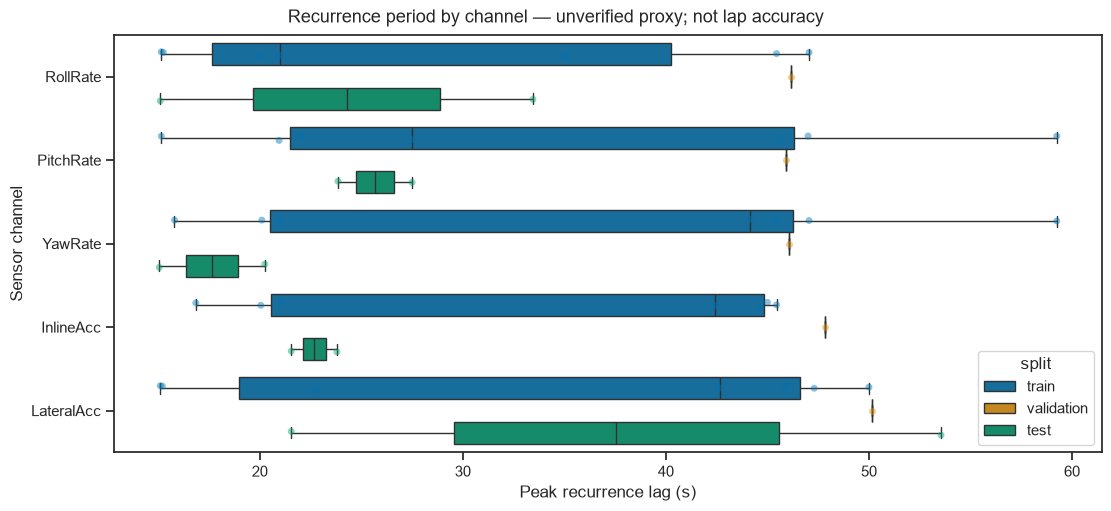

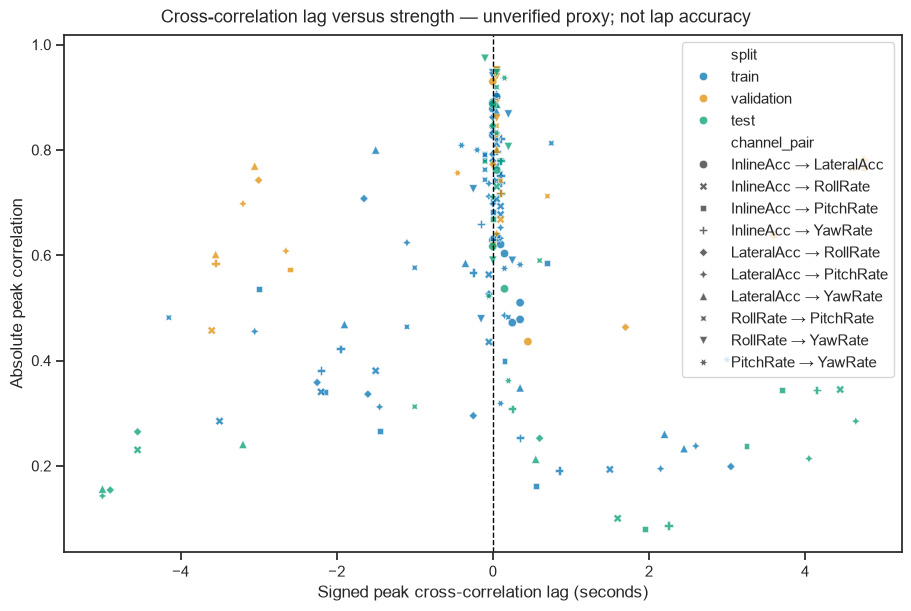

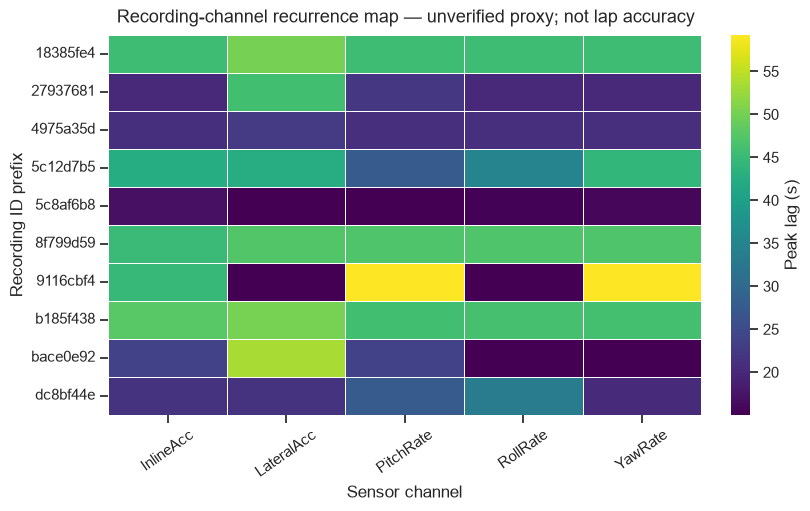

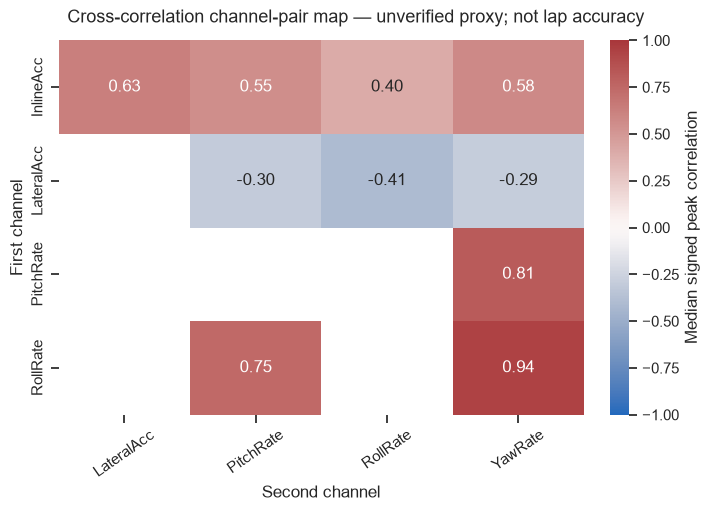

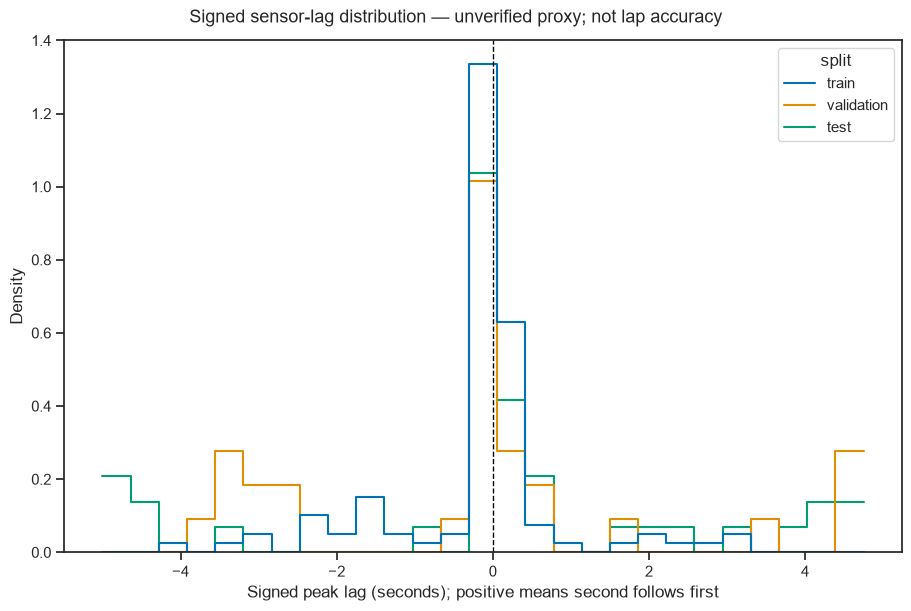

In [3]:
METHOD = "03_correlation"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_correlation_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,7.343
clock_provenance,inferred_uniform_from_metadata
sample_rate_hz,20.0
channels,"[InlineAcc, LateralAcc, RollRate, PitchRate, Y..."
label_provenance,unverified_channel_recurrence


## Reading

Low lag disagreement means channel consistency. Coupled sensors are not independent lap evidence.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.